# Carbon-24 Data Preprocessing & Feature Selection

**Dự án:** Khai thác dữ liệu cấu trúc Carbon-24  
**Mục tiêu:** Khảo sát, tiền xử lý, làm sạch dữ liệu và loại bỏ multicollinearity

## Nội dung:
1. Load và khảo sát dữ liệu
2. Phân tích phân phối
3. Phát hiện outliers
4. Phân tích tương quan
5. Xử lý outliers
6. Feature engineering
7. Loại bỏ multicollinearity
8. Chuẩn hóa dữ liệu
9. Lưu kết quả


In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.feature_selection import VarianceThreshold
import warnings
import os
import json

warnings.filterwarnings('ignore')

# Thiết lập style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print(" Libraries imported successfully!")


 Libraries imported successfully!


## 1. Load và Khảo Sát Dữ Liệu

In [2]:
# Load data
data_path = 'carbon24_features_v2/carbon24_project_v2/data/carbon24_features_v2.csv'
df = pd.read_csv(data_path)

print(f" Loaded {len(df)} samples with {len(df.columns)} features")
print(f" Shape: {df.shape}")
df.head()


 Loaded 10153 samples with 41 features
 Shape: (10153, 41)


,formula,elements,num_atoms,a,b,c,alpha,beta,gamma,volume,...,fraction_sp2,fraction_sp3,fraction_other,packing_fraction,row_index,split,source_file,material_id,energy,relative_energy
0,C,C,6,2.48053,5.09056,4.89497,57.97521,59.51109,43.04559,34.994539,...,0.0,1.0,0.0,0.327878,0,train,huggingface,C-130499-1826-36,-154.311891,0.244385
1,C,C,10,2.48986,4.65679,5.94592,90.03290,77.93642,57.67568,56.442646,...,0.0,1.0,0.0,0.338808,1,train,huggingface,C-13904-4247-31,-154.332183,0.224092
2,C,C,10,2.44168,4.79849,5.95909,119.73602,101.56104,75.51457,58.455462,...,0.2,0.8,0.0,0.327142,2,train,huggingface,C-92138-4782-35,-154.178157,0.378118
3,C,C,20,2.47518,4.18933,11.18377,100.54005,77.38712,89.87842,111.153317,...,0.0,1.0,0.0,0.344087,3,train,huggingface,C-192672-505-73,-154.309339,0.246936
4,C,C,6,3.39500,4.81978,3.65211,112.26885,128.35152,77.74360,43.348062,...,1.0,0.0,0.0,0.264693,4,train,huggingface,C-193956-5355-22,-154.141835,0.414440


In [3]:
# Dataset info
print("Dataset Information:")
print("="*80)
df.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10153 entries, 0 to 10152
Data columns (total 41 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   formula             10153 non-null  object 
 1   elements            10153 non-null  object 
 2   num_atoms           10153 non-null  int64  
 3   a                   10153 non-null  float64
 4   b                   10153 non-null  float64
 5   c                   10153 non-null  float64
 6   alpha               10153 non-null  float64
 7   beta                10153 non-null  float64
 8   gamma               10153 non-null  float64
 9   volume              10153 non-null  float64
 10  volume_per_atom     10153 non-null  float64
 11  density             10153 non-null  float64
 12  b_over_a            10153 non-null  float64
 13  c_over_a            10153 non-null  float64
 14  angle_deviation     10153 non-null  float64
 15  angle_std           10153 non-nu

In [4]:
# Descriptive statistics
df.describe()


,num_atoms,a,b,c,alpha,beta,gamma,volume,volume_per_atom,density,...,min_coordination,max_coordination,fraction_sp,fraction_sp2,fraction_sp3,fraction_other,packing_fraction,row_index,energy,relative_energy
count,10153.000000,10153.000000,10153.000000,10153.000000,10153.000000,10153.000000,10153.000000,10153.000000,10153.000000,10153.000000,...,10153.000000,10153.000000,10153.000000,10153.000000,10153.000000,10153.000000,10153.000000,10153.000000,10153.000000,10153.000000
mean,9.210874,2.781117,4.290537,5.811436,89.023794,89.680011,89.142957,58.375786,6.368217,3.165871,...,3.341081,3.781444,0.000438,0.401104,0.598227,0.000231,0.303554,5076.000000,-154.250522,0.305753
std,3.581725,0.569105,1.083084,1.604913,19.903713,15.519512,17.307498,22.645007,0.671452,0.323961,...,0.481518,0.418498,0.008101,0.389961,0.390183,0.005818,0.031062,2931.062976,0.136500,0.136500
min,6.000000,2.400840,2.400030,2.462910,30.211280,35.628980,33.278740,32.533810,5.422302,2.203330,...,2.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.211263,0.000000,-154.556985,-0.000710
25%,6.000000,2.456640,3.613200,4.650120,74.806360,78.682970,75.448090,43.093640,5.817078,2.810238,...,3.000000,4.000000,0.000000,0.000000,0.250000,0.000000,0.269455,2538.000000,-154.333489,0.222787
50%,8.000000,2.483090,4.202290,5.615850,89.947060,89.997290,89.994700,52.471316,6.137606,3.249514,...,3.000000,4.000000,0.000000,0.333333,0.666667,0.000000,0.311574,5076.000000,-154.217487,0.338788
75%,10.000000,3.041910,4.806930,6.579900,104.428830,100.896800,101.560390,69.013750,7.096993,3.428566,...,4.000000,4.000000,0.000000,0.750000,1.000000,0.000000,0.328743,7614.000000,-154.136999,0.419277
max,24.000000,6.507970,10.794770,17.316410,146.662720,140.737120,151.667550,175.034267,9.051862,3.678186,...,4.000000,5.000000,0.200000,1.000000,1.000000,0.333333,0.352677,10152.000000,-154.065602,0.490673


In [7]:
# Check missing values
missing = df.isnull().sum()
missing_pct = 100 * df.isnull().sum() / len(df)
missing_table = pd.DataFrame({
    'Missing Count': missing,
    'Percentage': missing_pct
})
missing_table = missing_table[missing_table['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

if len(missing_table) > 0:
    print("Missing Values:")
    display(missing_table)
else:
    print(" No missing values found!")


 No missing values found!


In [8]:
# Check duplicates
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

# Feature classification
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

print(f"\nNumeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")
print(f"\nCategorical: {categorical_features}")


Number of duplicate rows: 0

Numeric features: 34
Categorical features: 7

Categorical: ['formula', 'elements', 'space_group_symbol', 'crystal_system', 'split', 'source_file', 'material_id']


## 2. Phân Tích Phân Phối Dữ Liệu

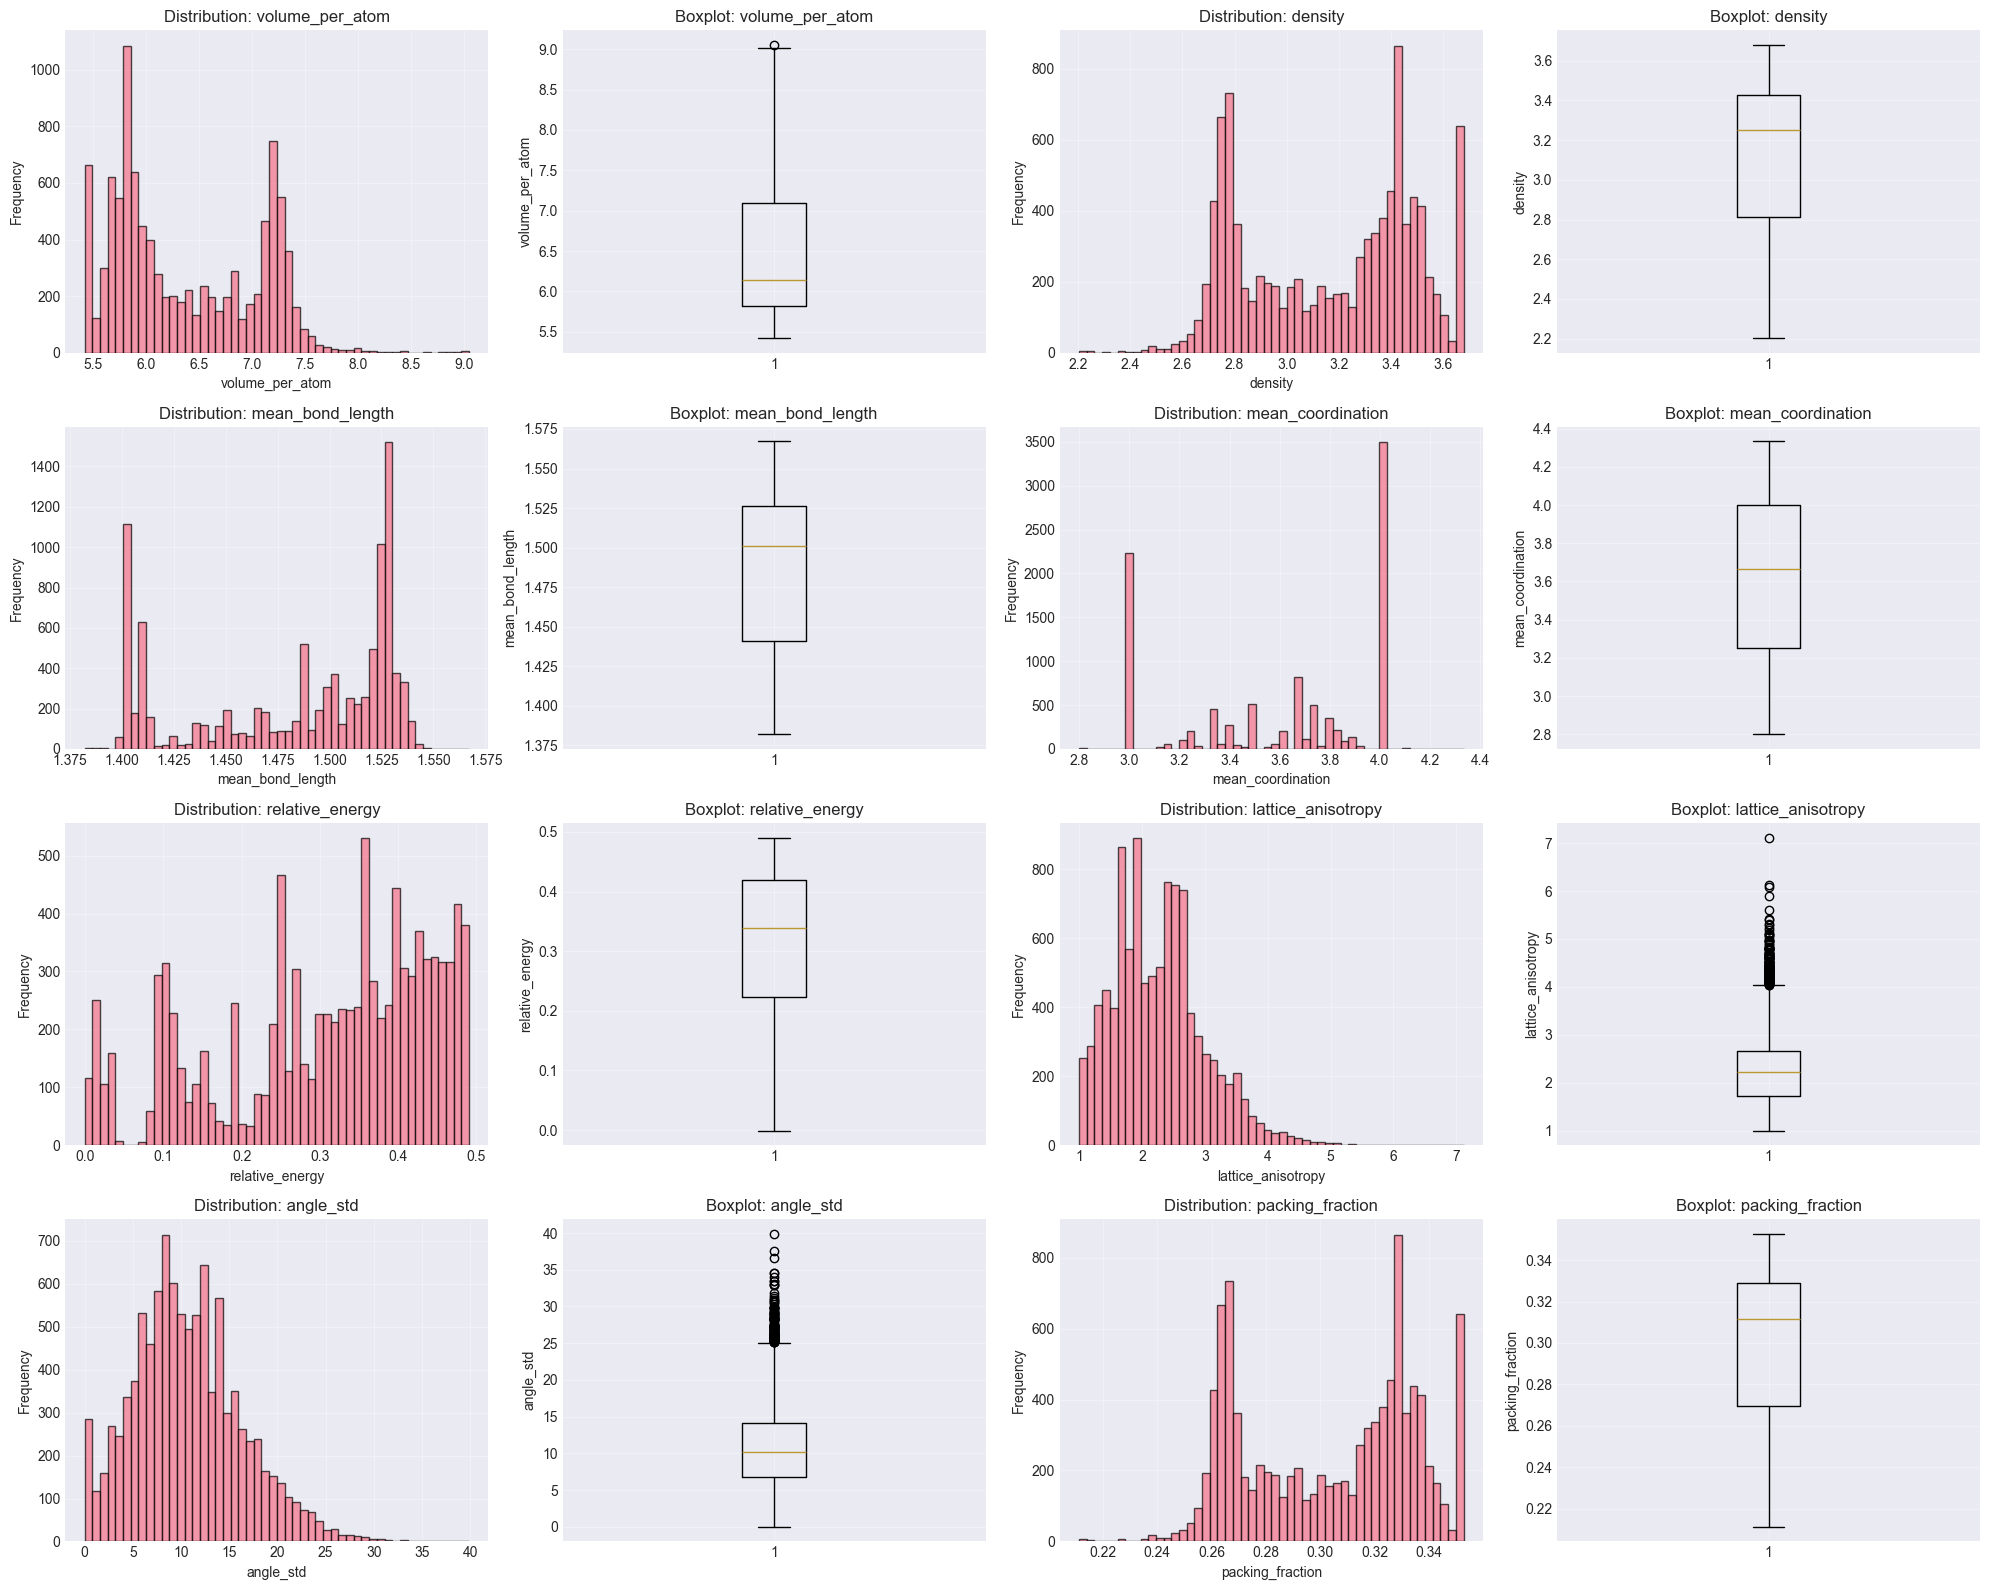

In [9]:
# Key features to analyze
key_features = [
    'volume_per_atom', 'density', 'mean_bond_length', 
    'mean_coordination', 'relative_energy',
    'lattice_anisotropy', 'angle_std', 'packing_fraction'
]

# Plot distributions
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.ravel()

for idx, feature in enumerate(key_features):
    # Histogram
    axes[idx*2].hist(df[feature].dropna(), bins=50, edgecolor='black', alpha=0.7)
    axes[idx*2].set_title(f'Distribution: {feature}')
    axes[idx*2].set_xlabel(feature)
    axes[idx*2].set_ylabel('Frequency')
    axes[idx*2].grid(True, alpha=0.3)
    
    # Boxplot
    axes[idx*2+1].boxplot(df[feature].dropna(), vert=True)
    axes[idx*2+1].set_title(f'Boxplot: {feature}')
    axes[idx*2+1].set_ylabel(feature)
    axes[idx*2+1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [10]:
# Skewness and Kurtosis
skew_kurt = pd.DataFrame({
    'Feature': key_features,
    'Skewness': [df[f].skew() for f in key_features],
    'Kurtosis': [df[f].kurtosis() for f in key_features]
})
print("Skewness & Kurtosis Analysis:")
display(skew_kurt)


Skewness & Kurtosis Analysis:


,Feature,Skewness,Kurtosis
0,volume_per_atom,0.397205,-1.084368
1,density,-0.186150,-1.326963
2,mean_bond_length,-0.649953,-1.138056
3,mean_coordination,-0.456816,-1.324031
4,relative_energy,-0.618390,-0.713846
5,lattice_anisotropy,0.711741,0.785005
6,angle_std,0.513419,0.338500
7,packing_fraction,-0.186150,-1.326963


## 3. Phát Hiện Outliers

In [11]:
def detect_outliers_iqr(data, feature):
    """Phát hiện outliers bằng IQR method"""
    Q1 = data[feature].quantile(0.25)
    Q3 = data[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[feature] < lower_bound) | (data[feature] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

def detect_outliers_zscore(data, feature, threshold=3):
    """Phát hiện outliers bằng Z-score method"""
    z_scores = np.abs(stats.zscore(data[feature].dropna()))
    outliers = len(z_scores[z_scores > threshold])
    return outliers

# Analyze outliers
outlier_summary = []
for feature in key_features:
    iqr_count, lower, upper = detect_outliers_iqr(df, feature)
    zscore_count = detect_outliers_zscore(df, feature)
    outlier_summary.append({
        'Feature': feature,
        'IQR_Outliers': iqr_count,
        'IQR_Percentage': f"{100*iqr_count/len(df):.2f}%",
        'ZScore_Outliers': zscore_count,
        'ZScore_Percentage': f"{100*zscore_count/len(df):.2f}%"
    })

outlier_df = pd.DataFrame(outlier_summary)
print("Outlier Detection Summary:")
display(outlier_df)


Outlier Detection Summary:


,Feature,IQR_Outliers,IQR_Percentage,ZScore_Outliers,ZScore_Percentage
0,volume_per_atom,1,0.01%,17,0.17%
1,density,0,0.00%,0,0.00%
2,mean_bond_length,0,0.00%,0,0.00%
3,mean_coordination,0,0.00%,0,0.00%
4,relative_energy,0,0.00%,0,0.00%
5,lattice_anisotropy,178,1.75%,75,0.74%
6,angle_std,120,1.18%,50,0.49%
7,packing_fraction,0,0.00%,0,0.00%


## 4. Phân Tích Tương Quan

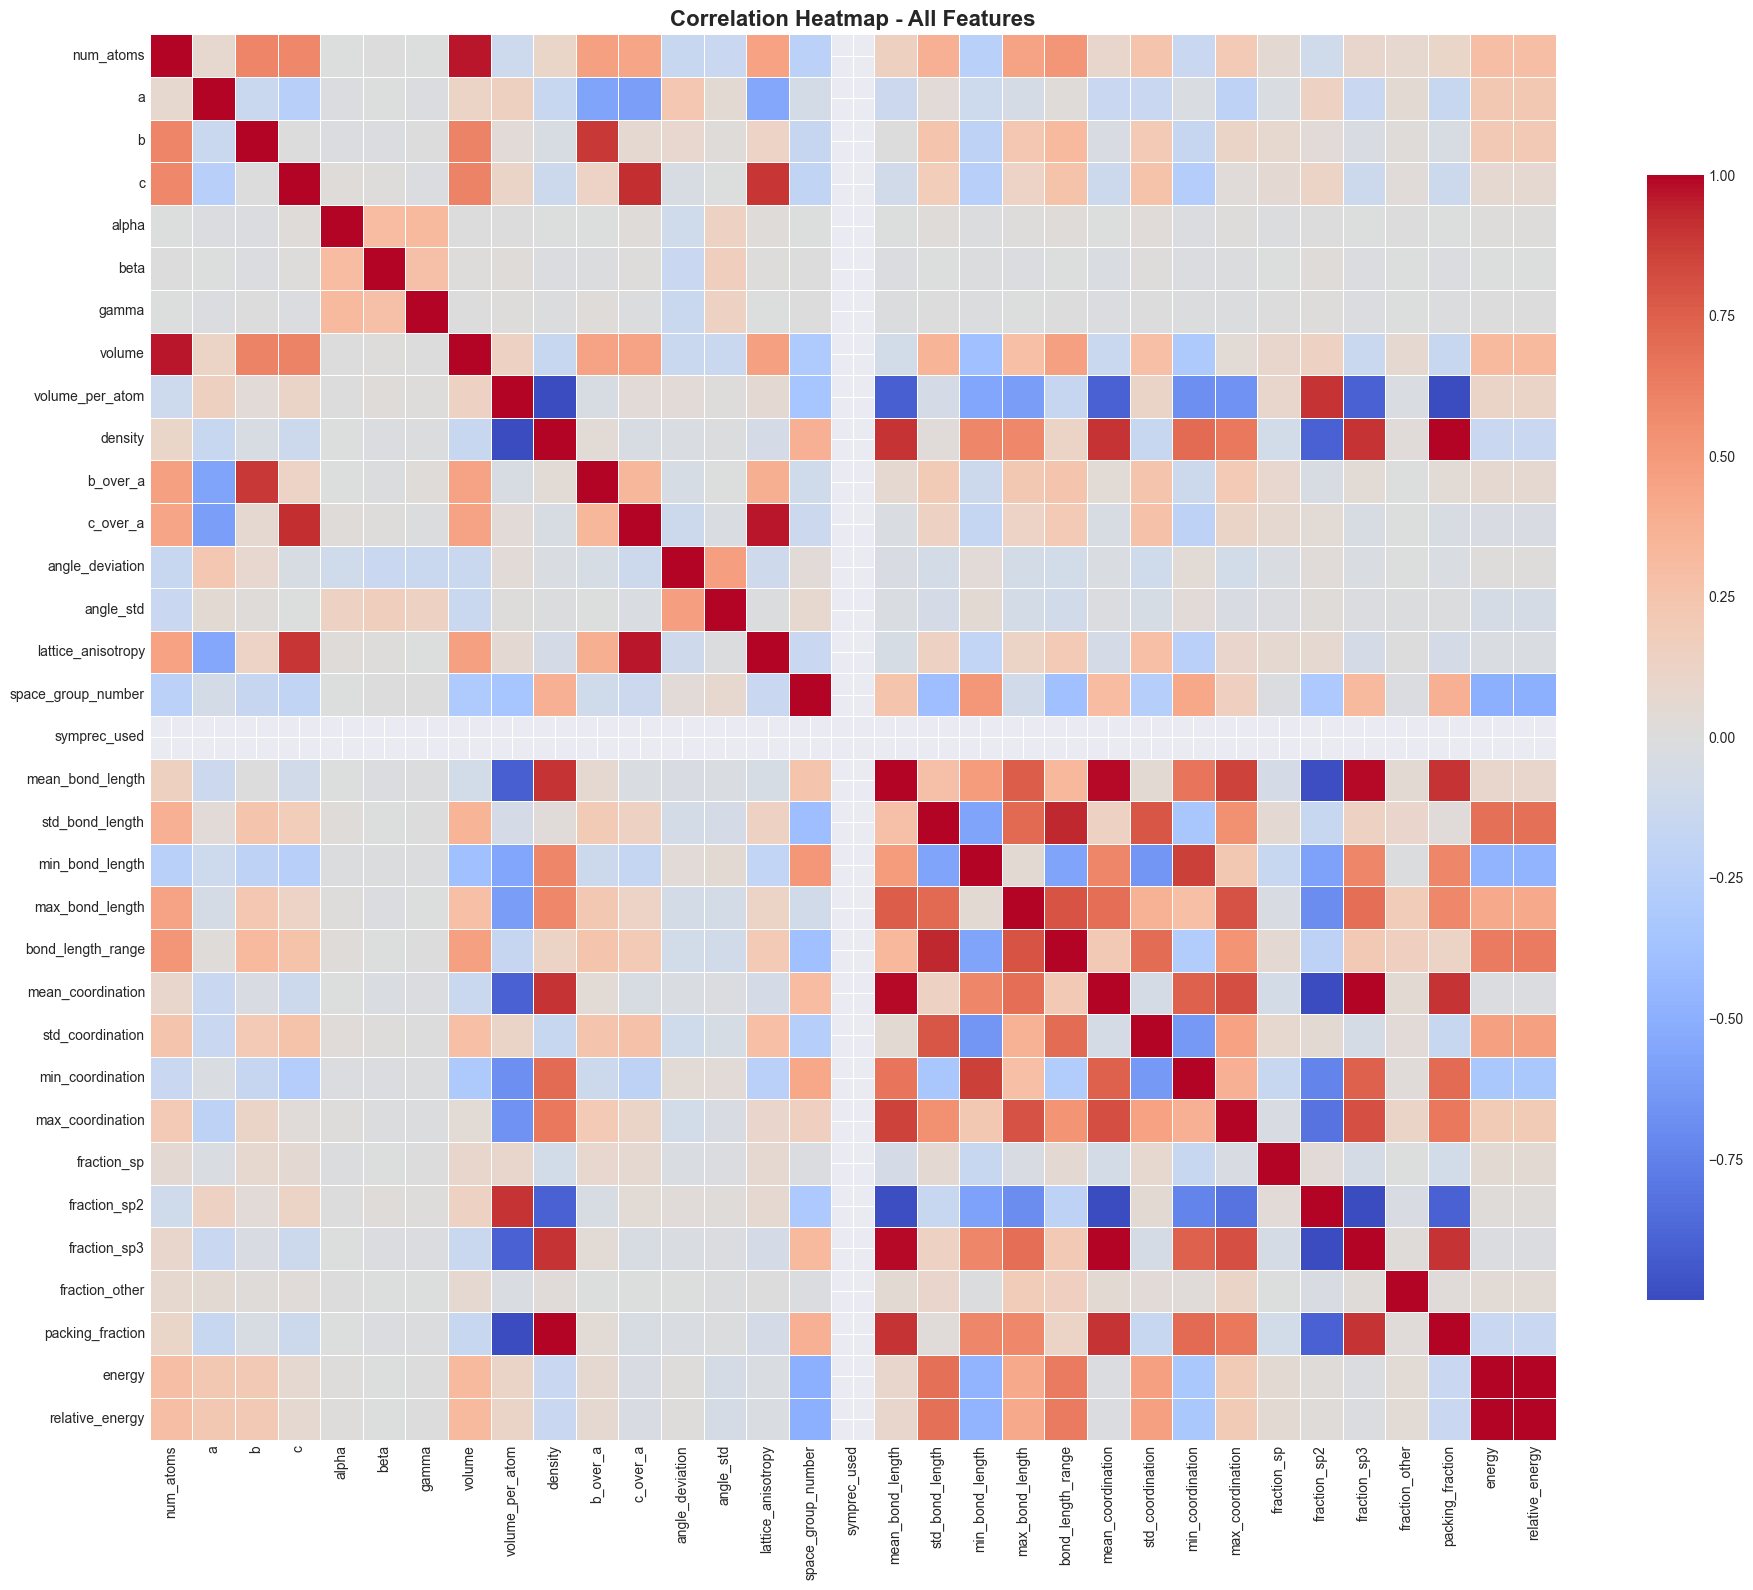

In [12]:
# Select numeric features for correlation analysis
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
exclude_cols = ['row_index']
analysis_cols = [col for col in numeric_cols if col not in exclude_cols]

# Correlation matrix
correlation_matrix = df[analysis_cols].corr()

# Plot heatmap
plt.figure(figsize=(20, 16))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap - All Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


In [13]:
# Find high correlation pairs
print("High Correlation Pairs (|r| > 0.8):")
print("="*80)

high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.8:
            high_corr_pairs.append({
                'Feature 1': correlation_matrix.columns[i],
                'Feature 2': correlation_matrix.columns[j],
                'Correlation': correlation_matrix.iloc[i, j]
            })

if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Correlation', 
                                                               key=abs, 
                                                               ascending=False)
    display(high_corr_df)
else:
    print("No high correlation pairs found.")


High Correlation Pairs (|r| > 0.8):


,Feature 1,Feature 2,Correlation
14,density,packing_fraction,1.000000
33,energy,relative_energy,1.000000
30,fraction_sp2,fraction_sp3,-0.999674
26,mean_coordination,fraction_sp3,0.999343
25,mean_coordination,fraction_sp2,-0.999031
9,volume_per_atom,packing_fraction,-0.996373
4,volume_per_atom,density,-0.996373
16,mean_bond_length,mean_coordination,0.986106
19,mean_bond_length,fraction_sp3,0.985524
18,mean_bond_length,fraction_sp2,-0.985370


## 5. Xử Lý Outliers

In [14]:
def winsorize_feature(data, feature, lower_percentile=0.01, upper_percentile=0.99):
    """Cap outliers at specified percentiles"""
    lower_bound = data[feature].quantile(lower_percentile)
    upper_bound = data[feature].quantile(upper_percentile)
    data[feature] = data[feature].clip(lower=lower_bound, upper=upper_bound)
    return data

# Apply winsorization
df_cleaned = df.copy()
features_to_winsorize = ['relative_energy', 'angle_std', 'lattice_anisotropy']

for feature in features_to_winsorize:
    if feature in df_cleaned.columns:
        df_cleaned = winsorize_feature(df_cleaned, feature, 0.01, 0.99)
        print(f" Winsorized: {feature}")

print(f"\n Cleaned dataset shape: {df_cleaned.shape}")


 Winsorized: relative_energy
 Winsorized: angle_std
 Winsorized: lattice_anisotropy

 Cleaned dataset shape: (10153, 41)


## 6. Feature Engineering

In [16]:
df_engineered = df_cleaned.copy()

# Volume ratio
if 'volume' in df_engineered.columns and 'num_atoms' in df_engineered.columns:
    df_engineered['volume_ratio'] = df_engineered['volume'] / df_engineered['num_atoms']

# Lattice asymmetry
if all(col in df_engineered.columns for col in ['b_over_a', 'c_over_a']):
    df_engineered['lattice_asymmetry'] = np.abs(df_engineered['b_over_a'] - 1) + \
                                          np.abs(df_engineered['c_over_a'] - 1)

# Bond complexity
if all(col in df_engineered.columns for col in ['std_bond_length', 'mean_bond_length']):
    df_engineered['bond_complexity'] = df_engineered['std_bond_length'] / \
                                        (df_engineered['mean_bond_length'] + 1e-10)

# Hybridization diversity
if all(col in df_engineered.columns for col in ['fraction_sp', 'fraction_sp2', 'fraction_sp3']):
    df_engineered['hybridization_diversity'] = -(
        df_engineered['fraction_sp'] * np.log(df_engineered['fraction_sp'] + 1e-10) +
        df_engineered['fraction_sp2'] * np.log(df_engineered['fraction_sp2'] + 1e-10) +
        df_engineered['fraction_sp3'] * np.log(df_engineered['fraction_sp3'] + 1e-10)
    )

new_features = [col for col in df_engineered.columns if col not in df_cleaned.columns]
print(f" Created {len(new_features)} new features:")
for feat in new_features:
    print(f"  - {feat}")


 Created 4 new features:
  - volume_ratio
  - lattice_asymmetry
  - bond_complexity
  - hybridization_diversity


## 7. Loại Bỏ Multicollinearity

Loại bỏ các features có tương quan cao (>0.95) để tránh redundancy và cải thiện hiệu suất mô hình.


In [17]:
# Features to drop based on high correlation analysis
features_to_drop = [
    'packing_fraction',      # r=1.0 với density
    'energy',                # r=1.0 với relative_energy
    'fraction_sp2',          # r=-0.9997 với fraction_sp3
    'fraction_sp3',          # r=0.9993 với mean_coordination
    'volume_per_atom',       # r=-0.996 với density
    'mean_coordination',     # r=0.999 với fraction_sp2
    'mean_bond_length',      # r=0.986 với mean_coordination
    'c_over_a',              # r=0.963 với lattice_anisotropy
    'volume',                # r=0.962 với num_atoms
    'lattice_anisotropy',    # r=0.959 với c_over_a
    'std_bond_length',       # r=0.936 với bond_length_range
    'std_coordination',      # r=0.997 với hybridization_diversity
    'b_over_a',              # r=0.885 với b
    'density',               # r=0.996 với volume_per_atom
]

# Remove features
features_to_keep = [col for col in df_engineered.columns if col not in features_to_drop]
df_reduced = df_engineered[features_to_keep].copy()

print(f"Original features: {len(df_engineered.columns)}")
print(f"Reduced features: {len(df_reduced.columns)}")
print(f"Removed: {len(features_to_drop)} features")
print(f"\nRemoved features: {sorted(features_to_drop)}")


Original features: 45
Reduced features: 31
Removed: 14 features

Removed features: ['b_over_a', 'c_over_a', 'density', 'energy', 'fraction_sp2', 'fraction_sp3', 'lattice_anisotropy', 'mean_bond_length', 'mean_coordination', 'packing_fraction', 'std_bond_length', 'std_coordination', 'volume', 'volume_per_atom']


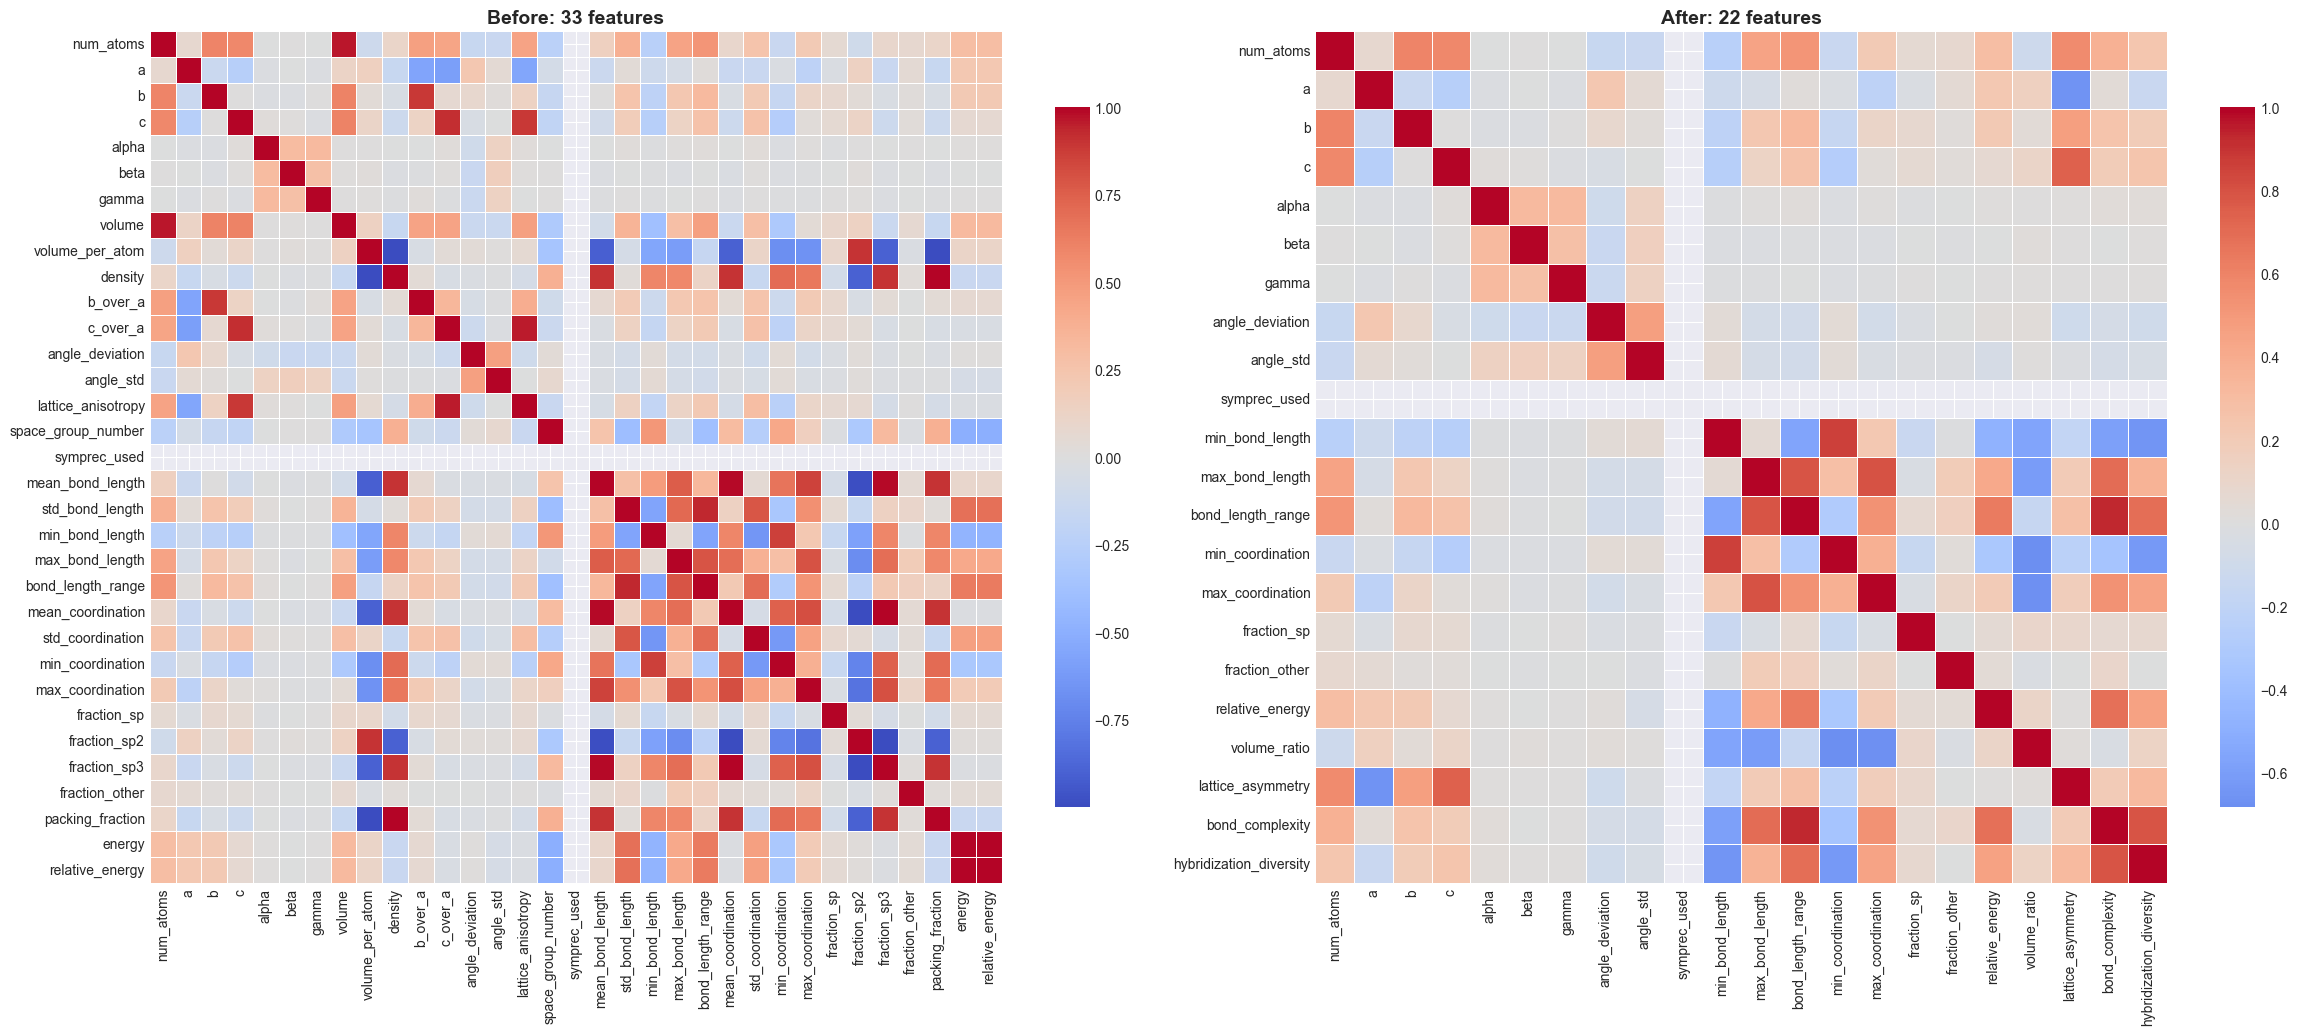

In [18]:
# Verify reduced correlation
numeric_reduced = df_reduced.select_dtypes(include=[np.number]).columns.tolist()
exclude_reduced = ['row_index', 'space_group_number']
analysis_reduced = [col for col in numeric_reduced if col not in exclude_reduced]

corr_matrix_reduced = df_reduced[analysis_reduced].corr().abs()

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(24, 10))

# Before
sns.heatmap(df_engineered[analysis_cols].corr(), ax=axes[0], cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
axes[0].set_title(f'Before: {len(analysis_cols)} features', fontsize=14, fontweight='bold')

# After
sns.heatmap(df_reduced[analysis_reduced].corr(), ax=axes[1], cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
axes[1].set_title(f'After: {len(analysis_reduced)} features', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


In [19]:
# Check remaining high correlations
upper_tri_reduced = corr_matrix_reduced.where(
    np.triu(np.ones(corr_matrix_reduced.shape), k=1).astype(bool)
)

high_corr_remaining = []
for column in upper_tri_reduced.columns:
    high_corr = upper_tri_reduced[column][upper_tri_reduced[column] > 0.90]
    for idx in high_corr.index:
        high_corr_remaining.append({
            'Feature 1': column,
            'Feature 2': idx,
            'Correlation': upper_tri_reduced[column][idx]
        })

if high_corr_remaining:
    print(f"  Still {len(high_corr_remaining)} pairs with |r| > 0.90:")
    remaining_df = pd.DataFrame(high_corr_remaining).sort_values('Correlation', ascending=False)
    display(remaining_df.head(10))
else:
    print(" No correlation pairs > 0.90 remaining!")


  Still 1 pairs with |r| > 0.90:


,Feature 1,Feature 2,Correlation
0,bond_complexity,bond_length_range,0.928429


## 8. Chuẩn Hóa Dữ Liệu

In [20]:
# Features to scale
features_to_scale = [col for col in df_reduced.select_dtypes(include=[np.number]).columns 
                     if col not in ['row_index', 'space_group_number']]

# StandardScaler
scaler_standard = StandardScaler()
df_standard = df_reduced.copy()
df_standard[features_to_scale] = scaler_standard.fit_transform(df_reduced[features_to_scale])

# RobustScaler
scaler_robust = RobustScaler()
df_robust = df_reduced.copy()
df_robust[features_to_scale] = scaler_robust.fit_transform(df_reduced[features_to_scale])

print(f" StandardScaler applied to {len(features_to_scale)} features")
print(f" RobustScaler applied to {len(features_to_scale)} features")


 StandardScaler applied to 22 features
 RobustScaler applied to 22 features


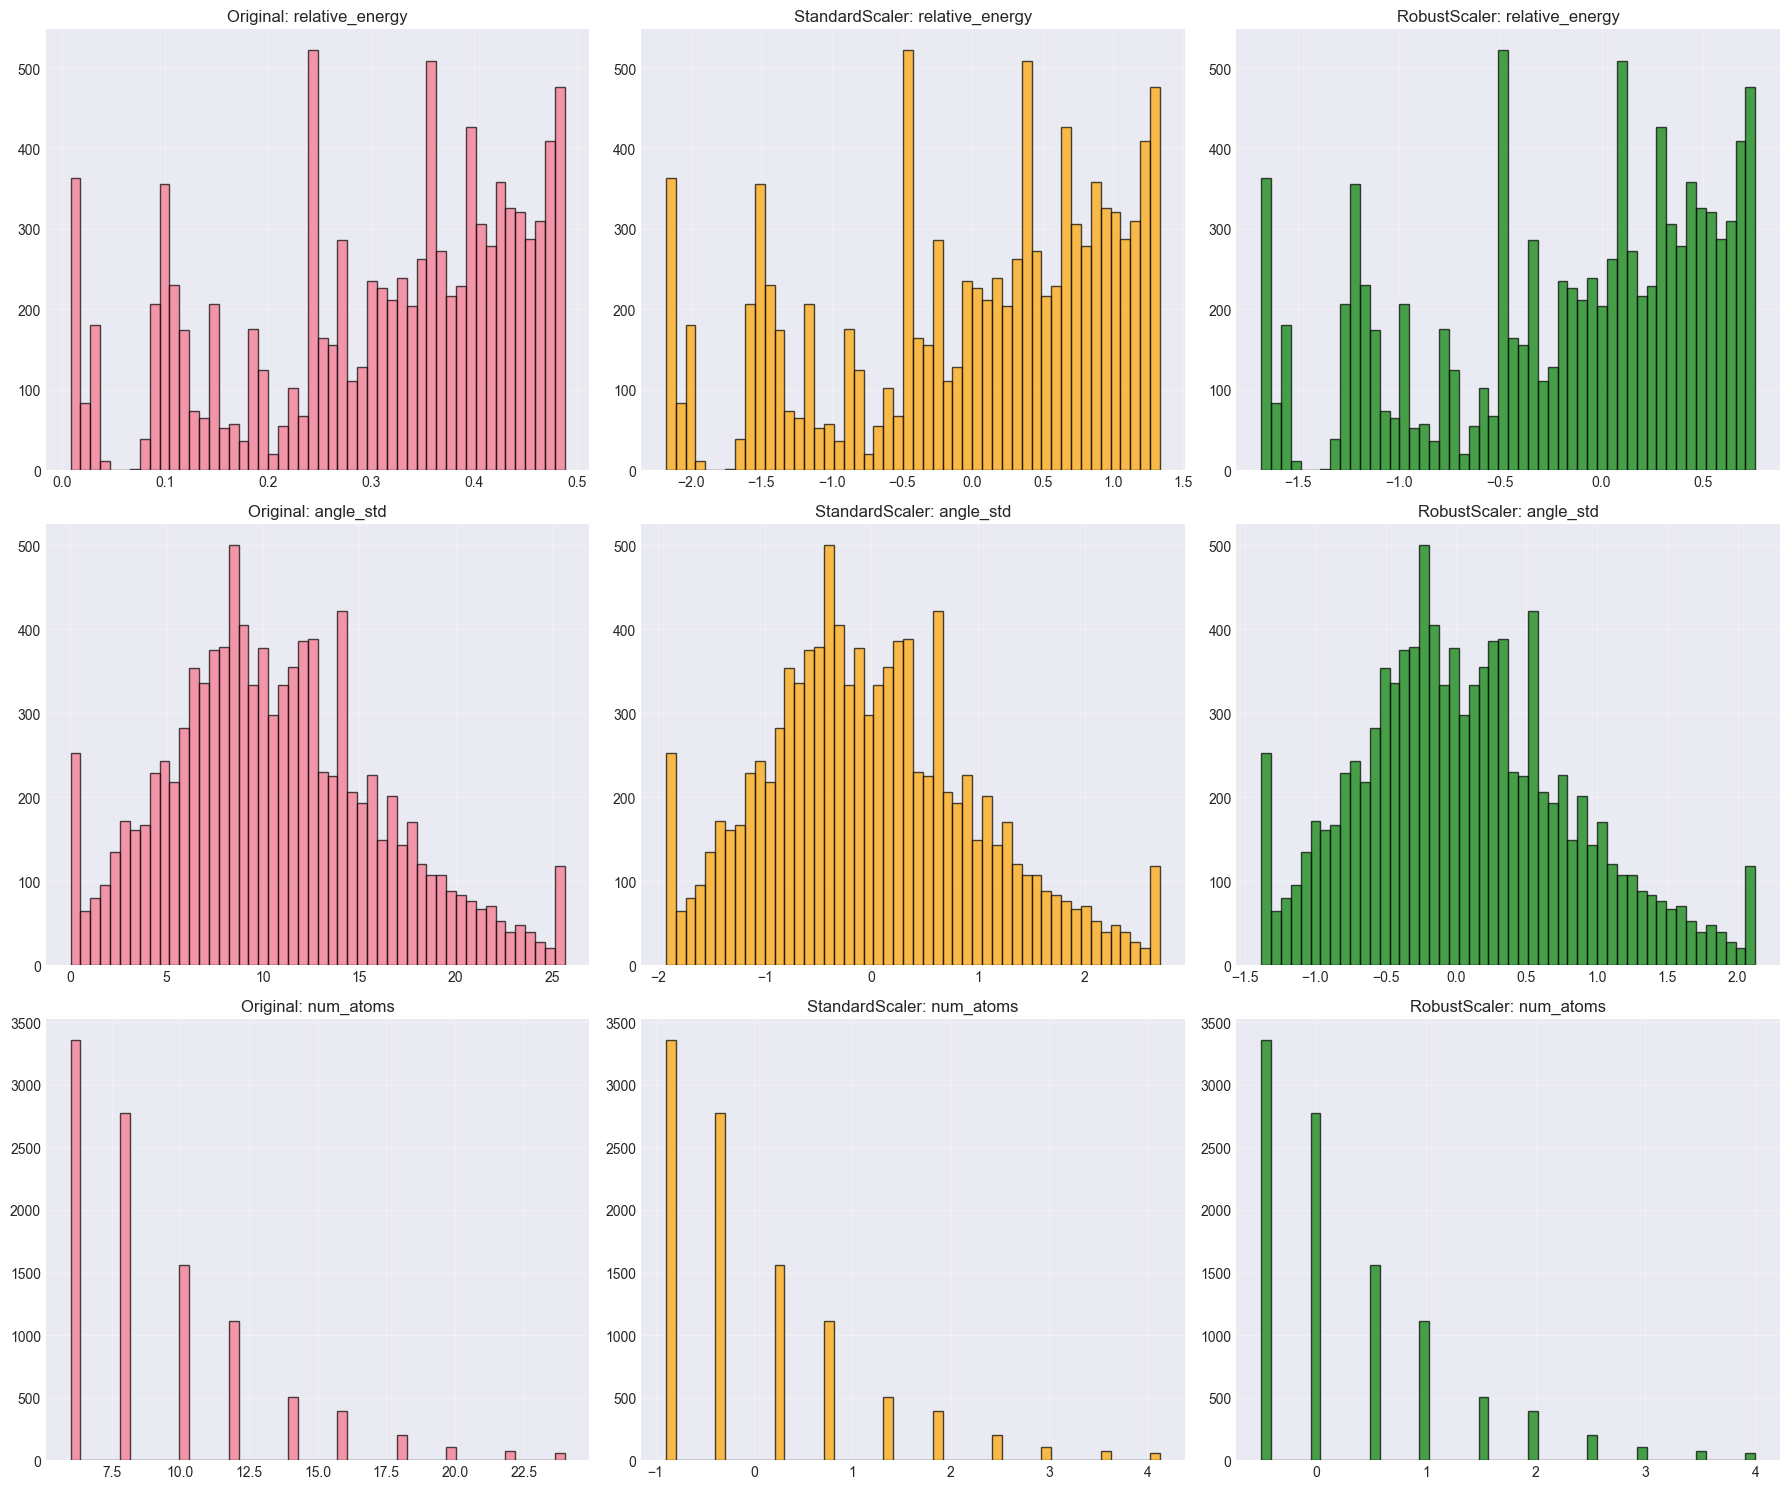

In [21]:
# Compare normalization methods
sample_features = ['relative_energy', 'angle_std', 'num_atoms']

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.ravel()

for idx, feature in enumerate(sample_features):
    if feature in df_reduced.columns:
        # Original
        axes[idx*3].hist(df_reduced[feature], bins=50, edgecolor='black', alpha=0.7)
        axes[idx*3].set_title(f'Original: {feature}')
        axes[idx*3].grid(True, alpha=0.3)
        
        # StandardScaler
        axes[idx*3+1].hist(df_standard[feature], bins=50, edgecolor='black', alpha=0.7, color='orange')
        axes[idx*3+1].set_title(f'StandardScaler: {feature}')
        axes[idx*3+1].grid(True, alpha=0.3)
        
        # RobustScaler
        axes[idx*3+2].hist(df_robust[feature], bins=50, edgecolor='black', alpha=0.7, color='green')
        axes[idx*3+2].set_title(f'RobustScaler: {feature}')
        axes[idx*3+2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 9. Phân Tích Theo Crystal System

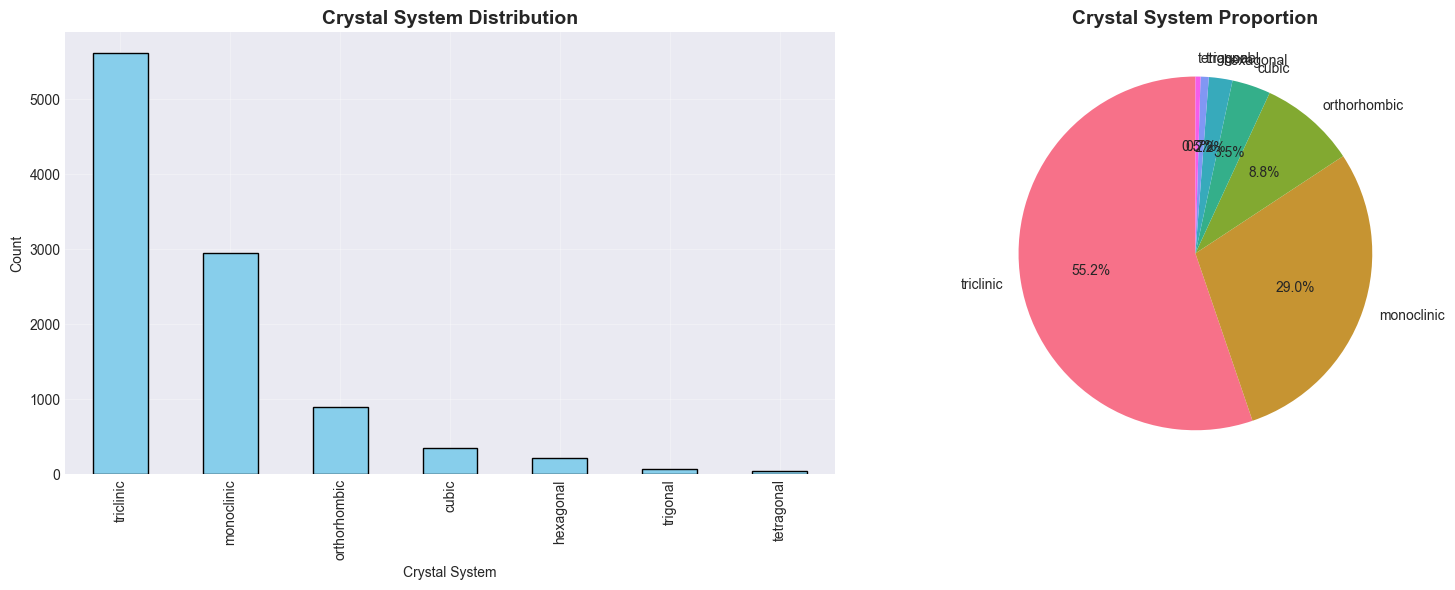


Crystal System Counts:


crystal_system
triclinic       5608
monoclinic      2948
orthorhombic     897
cubic            358
hexagonal        219
trigonal          76
tetragonal        47
Name: count, dtype: int64

In [22]:
if 'crystal_system' in df_reduced.columns:
    # Distribution
    crystal_counts = df_reduced['crystal_system'].value_counts()
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Bar plot
    crystal_counts.plot(kind='bar', ax=axes[0], color='skyblue', edgecolor='black')
    axes[0].set_title('Crystal System Distribution', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Crystal System')
    axes[0].set_ylabel('Count')
    axes[0].grid(True, alpha=0.3)
    
    # Pie chart
    axes[1].pie(crystal_counts, labels=crystal_counts.index, autopct='%1.1f%%', 
                startangle=90, colors=sns.color_palette('husl', len(crystal_counts)))
    axes[1].set_title('Crystal System Proportion', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print("\nCrystal System Counts:")
    display(crystal_counts)


In [23]:
# Energy by crystal system
if 'relative_energy' in df_reduced.columns and 'crystal_system' in df_reduced.columns:
    energy_by_crystal = df_reduced.groupby('crystal_system')['relative_energy'].agg([
        'count', 'mean', 'std', 'min', 'max'
    ]).round(4)
    
    print("Energy Statistics by Crystal System:")
    display(energy_by_crystal)


Energy Statistics by Crystal System:


,count,mean,std,min,max
crystal_system,,,,,
cubic,358,0.0268,0.0836,0.0087,0.4786
hexagonal,219,0.1030,0.0810,0.0160,0.3991
monoclinic,2948,0.2802,0.1220,0.0087,0.4879
orthorhombic,897,0.2972,0.0935,0.0095,0.4848
tetragonal,47,0.2284,0.0310,0.1324,0.3512
triclinic,5608,0.3506,0.1174,0.0087,0.4879
trigonal,76,0.0365,0.0455,0.0149,0.3899


## 10. Lưu Kết Quả

In [24]:
# Create output directory
output_dir = 'carbon24_preprocessing_results'
os.makedirs(output_dir, exist_ok=True)

# Save datasets
df_reduced.to_csv(f'{output_dir}/carbon24_feature_selected.csv', index=False)
df_standard.to_csv(f'{output_dir}/carbon24_feature_selected_standard.csv', index=False)
df_robust.to_csv(f'{output_dir}/carbon24_feature_selected_robust.csv', index=False)

print(" Saved datasets:")
print(f"  - {output_dir}/carbon24_feature_selected.csv")
print(f"  - {output_dir}/carbon24_feature_selected_standard.csv")
print(f"  - {output_dir}/carbon24_feature_selected_robust.csv")


 Saved datasets:
  - carbon24_preprocessing_results/carbon24_feature_selected.csv
  - carbon24_preprocessing_results/carbon24_feature_selected_standard.csv
  - carbon24_preprocessing_results/carbon24_feature_selected_robust.csv


In [ ]:
# Save feature lists
selected_features = {
    'all_features': features_to_keep,
    'numeric_features': analysis_reduced,
    'categorical_features': df_reduced.select_dtypes(include=['object']).columns.tolist(),
    'dropped_features': features_to_drop
}

with open(f'{output_dir}/selected_features.json', 'w') as f:
    json.dump(selected_features, f, indent=2)

print(f" Saved: {output_dir}/selected_features.json")


##  Summary

### Dataset Transformation:
- **Original:** 10,153 samples × 41 features
- **After Engineering:** 10,153 samples × 45 features
- **After Feature Selection:** 10,153 samples × 31 features
- **Features Removed:** 14 (multicollinearity)

### Key Steps Completed:
1.  Data loading and exploration
2.  Distribution analysis
3.  Outlier detection and handling
4.  Correlation analysis
5.  Feature engineering (4 new features)
6.  Multicollinearity removal (14 features dropped)
7.  Data normalization (StandardScaler & RobustScaler)
8.  Crystal system analysis
9.  Results saved
